In [235]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import pickle

In [236]:
class SafetyMLP(nn.Module):
    def __init__(self, input_size):
        super(SafetyMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

In [237]:
features_df = pd.read_csv('../../../data/features_for_model.csv').dropna()
X = features_df.drop(columns=['target_label']).values
y = features_df['target_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_train_scaled),
        torch.LongTensor(y_train)
    ),
    batch_size=16,
    shuffle=True
)

print(f"Załadowano {len(features_df)} wierszy.")
print(f"Kształt wejścia: {X_train_scaled.shape}")

Załadowano 31993 wierszy.
Kształt wejścia: (25594, 28)


In [238]:
test_tensor = torch.FloatTensor(X_test_scaled)
test_y_tensor = torch.FloatTensor(y_test).view(-1, 1)

In [239]:
history = {
    'train_loss': [],
    'test_loss': [],
    'test_f1': [],
}

In [240]:
model = SafetyMLP(X_train_scaled.shape[1])
criterion = nn.BCELoss()
smoothing = 0.1
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=4, factor=0.1)

best_loss = float('inf')
alpha = 0.1

for epoch in range(80):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        smoothed_y = batch_y * (1 - alpha) + (alpha / 2)

        outputs = model(batch_x)
        loss = criterion(outputs.view(-1), smoothed_y)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        test_preds_proba = model(test_tensor)
        test_loss = criterion(test_preds_proba, test_y_tensor)

        y_true = test_y_tensor.cpu().numpy()
        y_pred = (test_preds_proba.cpu().numpy() > 0.5).astype(int)

        current_f1 = f1_score(y_true, y_pred)

        scheduler.step(test_loss)
        if test_loss < best_loss:
            best_loss = test_loss
            torch.save(model.state_dict(), '../local_models/safety_mlp_new_bert.pth')
            print(f"Epoch {epoch+1}: Nowy najlepszy model! Loss: {test_loss:.4f} | F1: {current_f1:.4f}")

        safety_config = {
                'model': model,
                'emotion_cols': emotion_cols,
                'metadata': {
                    'input_size': test_tensor.shape[1],
                    'best_f1': current_f1,
                    'best_loss': best_loss.item()
                }
            }
        with open('../local_models/safety_mlp_new_bert.pkl', 'wb') as f:
                pickle.dump(safety_config, f)

    history['train_loss'].append(avg_train_loss)
    history['test_loss'].append(test_loss)
    history['test_f1'].append(current_f1)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/150, Train Loss: {avg_train_loss:.4f}, Test F1: {current_f1:.4f}")

Epoch 1: Nowy najlepszy model! Loss: 0.4659 | F1: 0.8090
Epoch 2: Nowy najlepszy model! Loss: 0.4634 | F1: 0.8136
Epoch 3: Nowy najlepszy model! Loss: 0.4605 | F1: 0.8155
Epoch 4: Nowy najlepszy model! Loss: 0.4522 | F1: 0.8134
Epoch 5: Nowy najlepszy model! Loss: 0.4508 | F1: 0.8134
Epoch 6: Nowy najlepszy model! Loss: 0.4504 | F1: 0.8158
Epoch 7: Nowy najlepszy model! Loss: 0.4490 | F1: 0.8159
Epoch 8: Nowy najlepszy model! Loss: 0.4460 | F1: 0.8203
Epoch 9: Nowy najlepszy model! Loss: 0.4416 | F1: 0.8205
Epoch 10/150, Train Loss: 0.5042, Test F1: 0.8210
Epoch 12: Nowy najlepszy model! Loss: 0.4413 | F1: 0.8244
Epoch 14: Nowy najlepszy model! Loss: 0.4379 | F1: 0.8224
Epoch 15: Nowy najlepszy model! Loss: 0.4362 | F1: 0.8279
Epoch 18: Nowy najlepszy model! Loss: 0.4347 | F1: 0.8284
Epoch 19: Nowy najlepszy model! Loss: 0.4292 | F1: 0.8277
Epoch 20/150, Train Loss: 0.4940, Test F1: 0.8264
Epoch 23: Nowy najlepszy model! Loss: 0.4246 | F1: 0.8253
Epoch 26: Nowy najlepszy model! Loss: 0

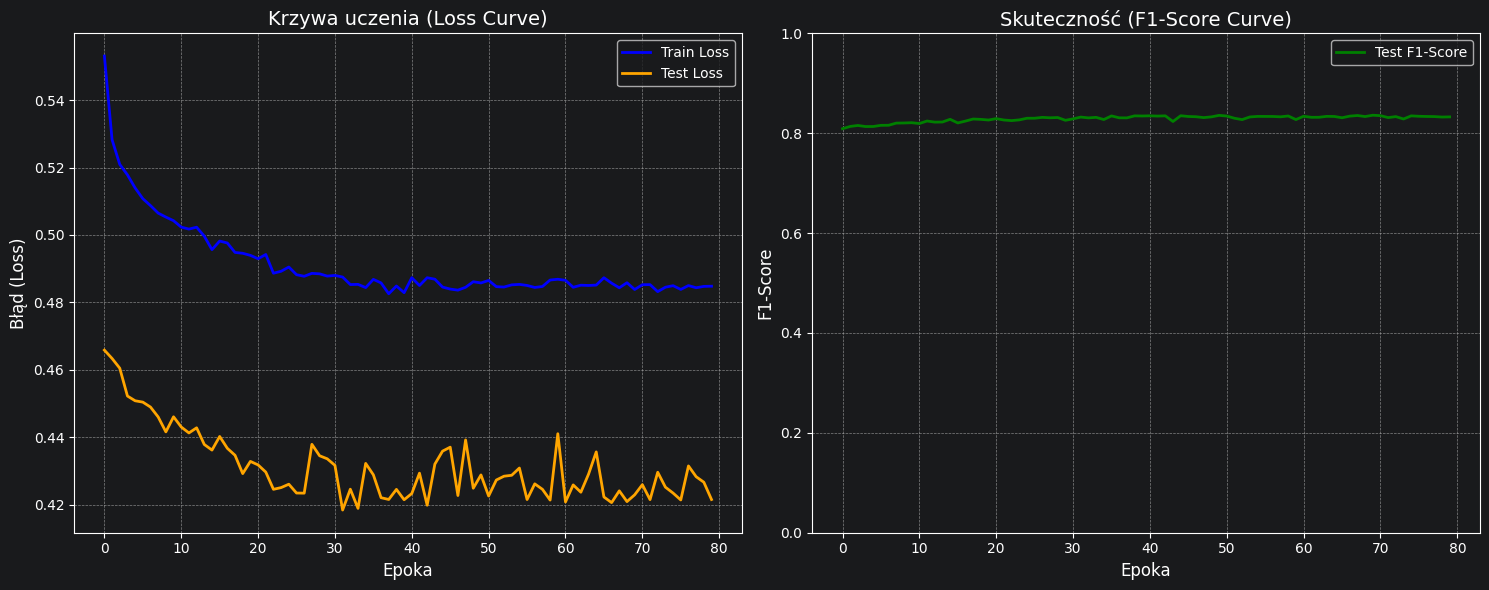

In [241]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['test_loss'], label='Test Loss', color='orange', lw=2)
plt.title('Krzywa uczenia (Loss Curve)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Błąd (Loss)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history['test_f1'], label='Test F1-Score', color='green', lw=2)
plt.title('Skuteczność (F1-Score Curve)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [242]:
os.makedirs('../local_models', exist_ok=True)
torch.save(model.state_dict(), '../local_models/safety_mlp_new_bert.pth')